# Calibrating runoff parameters in the OGGM

Parameters can currently (as of October 2025) only be calibrated in the OGGM in relation to the mass-balance, these parameters will be calibrated to the mass-balance and then used to extract the runoff parameters. These parameters will then be investigated to understand sensitvity against the calibrated parameters.

In this notebook we will:
- Use both OGGM calibration methods.
- Show how users can calibrate parameters and use these for runoff outputs to understand impact of parameter changes.
- Investigate the parameter sensitvity to the calibrations.

## Set Up

First install required packages to run this tutorial. 

We will be using level 4 data to allow for the dynamical spinup and the calibration capabilities.

In [35]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.sandbox.edu import run_constant_climate_with_bias
import xarray as xr
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb, mb_calibration_from_geodetic_mb, mb_calibration_from_wgms_mb

In [36]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2025-10-27 10:27:54: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-10-27 10:27:54: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-10-27 10:27:54: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-10-27 10:27:54: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-10-27 10:27:54: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-10-27 10:27:54: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [37]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-10-27 10:27:54: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-10-27 10:27:54: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


## Generating the Hydrological and Glaciological outputs

The pre-processed directories don't automatically have hydrological outputs, so lets run the `run_with_hydro` task below to calculate these! This requires a dynamical spinup, let's choose the time period 2000-2020.

In [38]:
# file identifier where the model output is saved
file_id = '_spinup'

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix='_spinup_historical')) as ds:
    ds = ds.sel(time=slice(2000, 2020)).load()

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds = ds.isel(time=slice(0, -1)).load()

Now that we have the hydrological and glaciological outputs for our desired timeperiod, lets calculate the total runoff for the glacier. There are four key variables that form the total runoff when summed together, and the process to calculate the runoff can be seen below.

The total runoff from the glacier is:
`runoff` = `melt_off_glacier` + `melt_on_glacier` + `liq_prcp_off_glacier` + `liq_prcp_on_glacier`


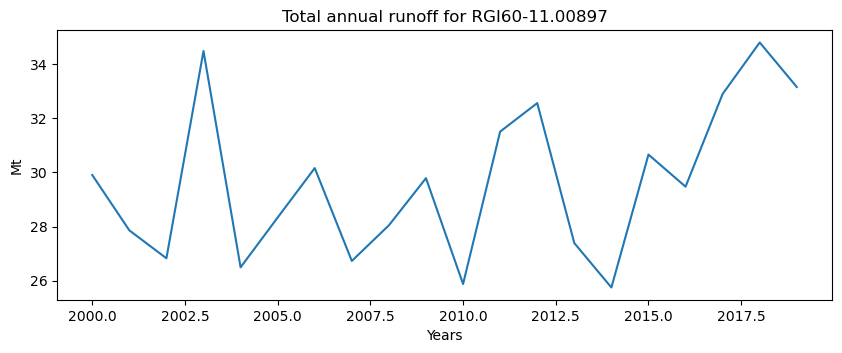

In [39]:
sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
df_annual = ds[sel_vars].to_dataframe()

df_annual

# These summed variabels give the total runoff from the glacier
runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

# Convert them to megatonnes (instead of kg)
df_runoff = df_annual[runoff_vars] * 1e-9
fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_runoff.sum(axis=1).plot(ax=ax);
plt.ylabel('Mt'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');


## Parameter Calibration

The mass-balance parameters at Level 4 are pre-calibrated automatically by the OGGM and stored in the dataframe. However there are flexible mass-balance calibration schemes in the OGGM.

There are two main methods of calibration within the OGGM:
1. The **scalar mass balance** method, which calibrates the parameters with only the average mass balance.
2. The **wgms mass balance** method, which calibrates the parameters with both the average mass balance and the internal invariability of the glacier.

In this tutorial, our aim is to calibrate the run-off and investigate the impact that this calibration has on the result. In the OGGM we can currently (at the time of writing this tutorial October 2025) only calibrate the melt_f, prcp_fac and temp_bias parameters. We will calibrate these parameters and investigate the relationship with the runoff parameters and total runoff output.

In this tutorial, we will start with the simpler, scalar mass balance method.

For more information on the calibration methods, we would recommend the tutorial on mass-balance calibration [massbalance_calibration.ipynb](https://tutorials.oggm.org/stable/notebooks/tutorials/massbalance_calibration.html).

### **Calibration Method 1:** Scalar Mass Balance Calibration

Firstly comparing the mass balances below for in-situ observations and the deafult calibrated parameters. To understand the current behaviour of the mass balance output.


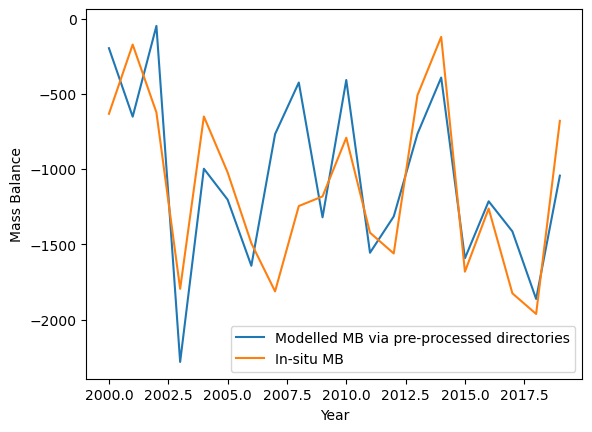

In [40]:
# First we get the insitu data for this glacier, since it exists
h, w = gdir_hef.get_inversion_flowline_hw()

mbmod = massbalance.MonthlyTIModel(gdir_hef)
mbdf= pd.DataFrame(index = np.arange(2000,2020,1))
mbdf['mod_mb'] = mbmod.get_specific_mb(fls=gdir_hef.read_pickle('inversion_flowlines'), year=np.arange(2000,2020,1))

mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

mbdf_in_situ = mbdf['in_situ_mb']

mbdf['mod_mb'].plot(label="Modelled MB via pre-processed directories")
mbdf['in_situ_mb'].plot(label="In-situ MB")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mass Balance");

Now let's experiment by calibrating the parameters: these parameters are the melt factor (`melt_f`), the precipitation factor (`prcp_fac`) and the temperature bias (`temp_bias`). We will calibrate each parameter and permutations of the calibrations:
1. Just calibrating `melt_f`
2. Just calibrating `prcp_fac`
3. Just calibrating `temp_bias`
4. Calibrating `melt_f` and `prcp_fac`
5. Calibrating `prcp_fac` and `temp_bias`
6. Calibrating `melt_f` and `temp_bias`
7. Calibrating all parameters; `melt_f`, `prcp_fac` and `temp_bias`

The next calibration section will be relatively repetative, but take note of the parameters being calibrated and the inputs being used in the calibration process.

We will start the calibration by just calibrating the model the `melt_f` paramater.

### Single Parameter Calibration

In [41]:
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_hef.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
# dmdtda: in meters water-equivalent per year -> we convert to kg m-2 yr-1
ref_mb = ref_mb_df['dmdtda'] * 1000
ref_mb

# Just calibrate the melt_f parameter
calib_param_melt_f = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f
mb_melt_f = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_melt_f'] = mb_melt_f.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_melt_f:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_melt_f = ds_melt_f.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_melt_f.variables if 'month_2d' not in ds_melt_f[v].dims]
df_annual_melt_f = ds_melt_f[sel_vars].to_dataframe()


Now calibrating the precipitation factor variable, `prcp_fac`:

In [42]:
# Just calibrate the prcp_fac parameter
calib_param_prcp_fac = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new prcp_fac
mb_prcp_fac = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_prcp_fac'] = mb_prcp_fac.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_prcp_fac:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_prcp_fac = ds_prcp_fac.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_prcp_fac.variables if 'month_2d' not in ds_prcp_fac[v].dims]
df_annual_prcp_fac = ds_prcp_fac[sel_vars].to_dataframe()

Now calibrating the temperature bias parameter, `temp_bias`:

In [43]:
# Just calibrate the temp_bias parameters
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new temp_bias
mb_temp_bias = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_temp_bias'] = mb_temp_bias.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_temp_bias:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_temp_bias = ds_temp_bias.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_temp_bias.variables if 'month_2d' not in ds_temp_bias[v].dims]
df_annual_temp_bias = ds_temp_bias[sel_vars].to_dataframe()

### Calibrating permutations of two parameters together

Now calibrating `melt_f` and `prcp_fac`:

In [44]:
# Calibrating the melt_f and prcp_fac parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f and prcp_fac
mb_mf_pf = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_mf_pf'] = mb_mf_pf.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_pf:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_pf = ds_mf_pf.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_pf.variables if 'month_2d' not in ds_mf_pf[v].dims]
df_annual_mf_pf = ds_mf_pf[sel_vars].to_dataframe()

Calibrating `prcp_fac` and `temp_bias`:

In [45]:
# Calibrating the prcp_fac and temp_bias parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new prcp_fac and temp_bias
mb_pf_tb = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_pf_tb'] = mb_pf_tb.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_pf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_pf_tb = ds_pf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated prcp_fac parameter
sel_vars = [v for v in ds_pf_tb.variables if 'month_2d' not in ds_pf_tb[v].dims]
df_annual_pf_tb = ds_pf_tb[sel_vars].to_dataframe()

Calibrating `melt_f` and `temp_bias`:

In [46]:
# Calibrating the melt_f and temp_bias parameters together
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new melt_f and temp_bias
mb_mf_tb = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_mf_tb'] = mb_mf_tb.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_tb = ds_mf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_tb.variables if 'month_2d' not in ds_mf_tb[v].dims]
df_annual_mf_tb = ds_mf_tb[sel_vars].to_dataframe()

Now calibrating `melt_f`, `prcp_fac` and `temp_bias` together at the same time:

### Calibrating all three parameters together

In [47]:
# Calibrate all of the parameters
mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb, 
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              calibrate_param3='temp_bias',
                              overwrite_gdir=True)

# Calculate the mass balance time series with the new parameters
mb_calib = massbalance.MonthlyTIModel(gdir_hef)
mbdf['mod_mb_calib'] = mb_calib.get_specific_mb(h ,w, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_calib:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_calib = ds_calib.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_calib.variables if 'month_2d' not in ds_calib[v].dims]
df_annual_calib = ds_calib[sel_vars].to_dataframe()

Now convert the runoff values to megatonnes for readability, and plotting runoff output values resulting from all calibration of parameters.

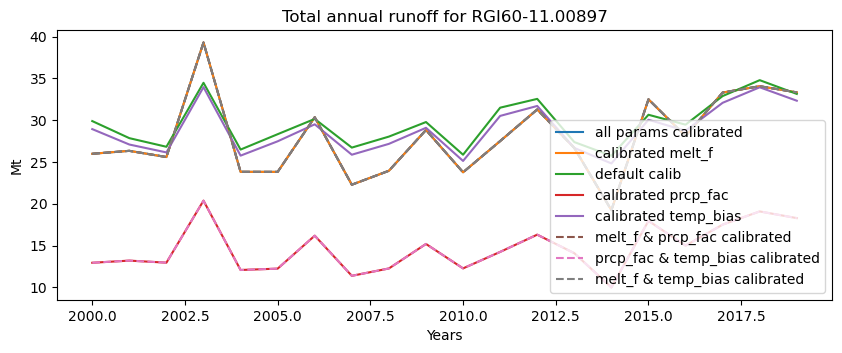

In [48]:
# Convert them to megatonnes (instead of kg)
df_runoff_melt_f = df_annual_melt_f[runoff_vars] * 1e-9
df_runoff_prcp_fac = df_annual_prcp_fac[runoff_vars] * 1e-9
df_runoff_temp_bias = df_annual_temp_bias[runoff_vars] * 1e-9
df_calib = df_annual_calib[runoff_vars] * 1e-9
df_runoff_mf_pf = df_annual_mf_pf[runoff_vars] * 1e-9
df_runoff_pf_tb = df_annual_pf_tb[runoff_vars] * 1e-9
df_runoff_mf_tb = df_annual_mf_tb[runoff_vars] * 1e-9

fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_calib.sum(axis=1).plot(ax=ax, label='all params calibrated');
df_runoff_melt_f.sum(axis=1).plot(ax=ax, label='calibrated melt_f');
df_runoff.sum(axis=1).plot(ax=ax, label='default calib');
df_runoff_prcp_fac.sum(axis=1).plot(ax=ax, label='calibrated prcp_fac');
df_runoff_temp_bias.sum(axis=1).plot(ax=ax, label='calibrated temp_bias');
df_runoff_mf_pf.sum(axis=1).plot(ax=ax, label='melt_f & prcp_fac calibrated', linestyle='dashed');
df_runoff_pf_tb.sum(axis=1).plot(ax=ax, label='prcp_fac & temp_bias calibrated', linestyle='dashed');
df_runoff_mf_tb.sum(axis=1).plot(ax=ax, label='melt_f & temp_bias calibrated', linestyle='dashed');
plt.ylabel('Mt'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');
plt.legend();

It can be seen in the graph above that a few different permutation of parameters being tuned lead to the same runoff results.

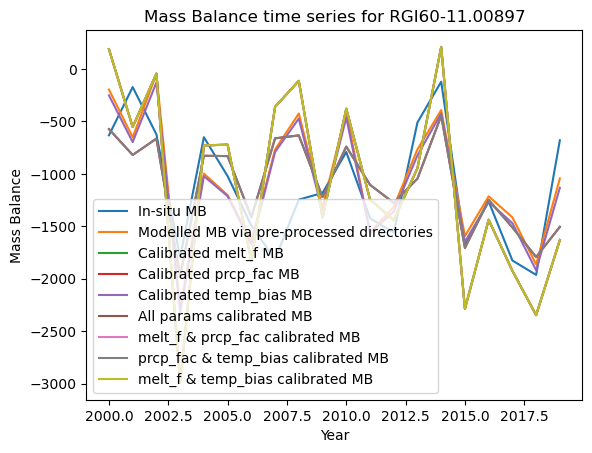

In [49]:
plt.plot(mbdf['in_situ_mb'], label='In-situ MB')
plt.plot(mbdf['mod_mb'], label='Modelled MB via pre-processed directories')
plt.plot(mbdf['mod_mb_melt_f'], label='Calibrated melt_f MB')
plt.plot(mbdf['mod_mb_prcp_fac'], label='Calibrated prcp_fac MB')
plt.plot(mbdf['mod_mb_temp_bias'], label='Calibrated temp_bias MB')
plt.plot(mbdf['mod_mb_calib'], label='All params calibrated MB')
plt.plot(mbdf['mod_mb_mf_pf'], label='melt_f & prcp_fac calibrated MB')
plt.plot(mbdf['mod_mb_pf_tb'], label='prcp_fac & temp_bias calibrated MB')
plt.plot(mbdf['mod_mb_mf_tb'], label='melt_f & temp_bias calibrated MB')
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mass Balance");
plt.title(f'Mass Balance time series for {rgi_id}');

# Here, melt_f calibrated and all params calibrated give very similar results and overlap, similarly as within the run off timeseries

We now have these different mass-balance results based off of our combinations of parameter calibration.

We can now investigate a bit further, and investigate the relationship between `prcp_fac` and `melt_on_glacier`. We will do this by fixing the `prcp_fac` value and calibrating the `melt_f` to obtain a range of calibrated values. This will allow us to verify the sensitivity of these parameters.

## Sensitivity Analysis of runoff parameters in calibration

We will now investigate the sensitivity of the runoff parameters to the calibration of the mass-balance parameters below. This will allow us to understand the relationship between parameters further, for example if one parameter is changed, how much does this affect the other parameter?

And in this tutorial we will investigate the sensitivity `melt_on_glacier` parameter and the melt contribution, which is:

$ \frac{\text{melt on glacier}}{\text{runoff`}}$ over the `prcp_fac`.

#TODO: Why choose these parameters?

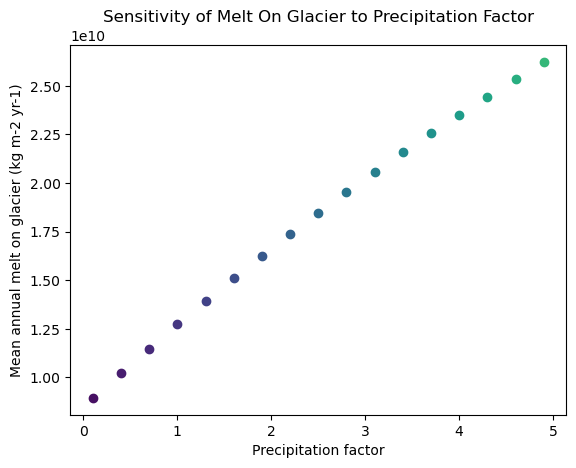

In [50]:
# Varying melt_f between a range of values with a step of 1.0

pd_prcp_sens = pd.DataFrame(index=np.arange(0.1, 5.0, 0.3))

# Calibrate the melt factor for each value
spec_mb_melt_f_sens_dict = {}
for pf in pd_prcp_sens.index:
    calib_param = mb_calibration_from_scalar_mb(gdir_hef,
                                  ref_mb = ref_mb, 
                                  prcp_fac = pf,
                                  ref_period=cfg.PARAMS['geodetic_mb_period'],
                                  overwrite_gdir=True)
    
    # Fill the dataframe with the calibrated parameters
    pd_prcp_sens.loc[pf, 'melt_f'] = calib_param['melt_f']
    
    # Calculate the mass balance time series with the new melt_f
    mb_melt_f_sens = massbalance.MonthlyTIModel(gdir_hef)

    annual_mb = mb_melt_f_sens.get_specific_mb(h ,w, year=np.arange(2000,2020,1))
    spec_mb_melt_f_sens_dict[pf] = annual_mb

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                        run_task=tasks.run_from_climate_data, # running from observed climate data
                        ys=2000,  # Period which we will average and constantly repeat
                        init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                        store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                        output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_sens:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds_sens = ds_sens.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds_sens.variables if 'month_2d' not in ds_sens[v].dims]
    df_annual_sens = ds_sens[sel_vars].to_dataframe()

    pd_prcp_sens.loc[pf, 'melt_off_glacier'] = df_annual_sens['melt_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'melt_on_glacier'] = df_annual_sens['melt_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] = df_annual_sens['liq_prcp_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier'] = df_annual_sens['liq_prcp_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'runoff'] = pd_prcp_sens.loc[pf, 'melt_off_glacier'] + pd_prcp_sens.loc[pf, 'melt_on_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier']

colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
    plt.title('Sensitivity of Melt On Glacier to Precipitation Factor')

# Here we are varying the precipitation factor and calibrating the melt factor for each value
# Then plotting the mean annual melt_on_glacier against the precipitation factor

In the above plot, a strong linear positive correlation is shown between the precipitation factor and the mean annual melt on the glacier. 

From the calibration, it can be seen that as the precipitation factor is changed, the melt factor parameter is calibrated accordingly and changes with the precipitation factor.

In the OGGM, the `melt_on_glacier` is derived from both the `melt_f` parameter and `prcp_fac`. Therefore this sensitivity makes sense.

Now investigating the sensitivity of the Glacier Melt Contribution to the Precipitation Factor.

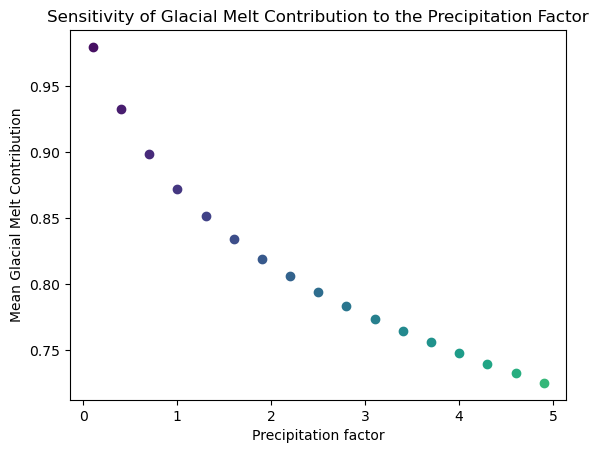

In [51]:
colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier']/pd_prcp_sens.loc[pf, 'runoff'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean Glacial Melt Contribution')
    plt.title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

# Here we are plotting how the glacial melt contribution (melt_on_glacier/runoff) varies with the changing precipitation factor
# This shows how the relative contribution of glacier melt to total runoff changes as we adjust precipitation

It can be seen that there is a relatively strong negative correlation, between the precipitation factor and the mean glacial melt contribution. And therefore it can be seen that the mean glacial melt contribution is quite sensitive to the change in precipitation factor.

Based off of the previous analysis and indication of a relationship between `prcp_fac` and `melt_on_glacier` the sensitvity of the `melt_on_glacier` parameter makes sense.

### **Calibration Method 2:** Calibration on Direct Glaciological In-Situ Mass Balance Observations

This is the second type of mass-balance calibration that we have in the OGGM that calibrates to both the mass-balance (as in the scalar case), and the internal invariability of the glacier.

The first method used (**scalar mass-balance calibration**) is an ill-posed problem in the case that there are more parameters being calibrated than the known values in which we are tuning the parameters to. This introduces the issue of **equifinality due to overparametrisation**, which means there are many parameters in which their combinations can lead to the same, expected result. Unfortunately this means that we may receive many plausible solutions, obtaining the correct target value. And will need to disentangle which parameter sets are truly representative.

This second calibration method reduces this issue slightly as we are now calibrating the three parameters to two targets, however this problem is still ill-posed, but slighly less ill-posed than before. Despite this second method marginally reducing this issue, this is not the default methodology used in OGGM since it relies on the glacier having WGMS data avaliable. This is because only 268 out of the ~20,000 Glaciers in the OGGM have the required WGMS data required for this calibration (more information on this can be found at [Reference Mass Balance Data](https://docs.oggm.org/en/stable/reference-mass-balance-data.html)).

Fortunately, the Hintereisferner glacier we are investigating in this tutorial has the required data for the calibration!


In [52]:
wgms_mbdf= pd.DataFrame(index = np.arange(2000,2020,1))
# These summed variabels give the total runoff from the glacier
runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

Now obtain the hydrological data to investigate the runoff values:

### Calibrating with Single Parameters

Calibate the melt factor variable, `melt_f`:

In [53]:
# Calculate the mass balance time series with the new melt_f

# To start with, calibrate with melt_f only
wgms_calib_melt_f = mb_calibration_from_wgms_mb(gdir_hef, overwrite_gdir=True)

wgms_mb_melt_f = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_melt_f'] = wgms_mb_melt_f.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_melt_f:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_melt_f = wgms_ds_melt_f.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_melt_f.variables if 'month_2d' not in wgms_ds_melt_f[v].dims]
wgms_df_annual_melt_f = ds_melt_f[sel_vars].to_dataframe()

Now just calibrating `prcp_fac`:

In [54]:
# Calibrate with prcp_fac only
wgms_calib_prcp_fac = mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='prcp_fac',
                                                overwrite_gdir=True)

wgms_mb_prcp_fac = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_prcp_fac'] = wgms_mb_prcp_fac.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_prcp_fac:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_prcp_fac = wgms_ds_prcp_fac.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_prcp_fac.variables if 'month_2d' not in wgms_ds_prcp_fac[v].dims]
wgms_df_annual_prcp_fac = wgms_ds_prcp_fac[sel_vars].to_dataframe()

Now just calibrating `temp_bias`:

In [55]:
# Calibrate with temp_bias only
wgms_calib_temp_bias = mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='temp_bias',
                                                overwrite_gdir=True)

wgms_mb_temp_bias = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_temp_bias'] = wgms_mb_temp_bias.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_temp_bias:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_temp_bias = wgms_ds_temp_bias.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_temp_bias.variables if 'month_2d' not in wgms_ds_temp_bias[v].dims]
wgms_df_annual_temp_bias = wgms_ds_temp_bias[sel_vars].to_dataframe()

### Calibrating with Pairs of Parameters

Now calibrating both `melt_f` and `prcp_fac`:

In [56]:
# Ccalibrate with melt_f and prcp_fac together
wgms_calib_mf_pf = mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='melt_f',
                                                calibrate_param2='prcp_fac',
                                                overwrite_gdir=True)

wgms_mb_mf_pf = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_mf_pf'] = wgms_mb_mf_pf.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_mf_pf:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_mf_pf = wgms_ds_mf_pf.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_mf_pf.variables if 'month_2d' not in wgms_ds_mf_pf[v].dims]
wgms_df_annual_mf_pf = wgms_ds_mf_pf[sel_vars].to_dataframe()

Now calibrating both `prcp_fac` and `temp_bias`:

In [57]:
# Next,calibrate with prcp_fac and temp_bias
wgms_calib_pf_tb = mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='prcp_fac',
                                                calibrate_param2='temp_bias',
                                                overwrite_gdir=True)

wgms_mb_pf_tb = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_pf_tb'] = wgms_mb_pf_tb.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_pf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_pf_tb = wgms_ds_pf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_pf_tb.variables if 'month_2d' not in wgms_ds_pf_tb[v].dims]
wgms_df_annual_pf_tb = wgms_ds_pf_tb[sel_vars].to_dataframe()

Now calibrating both `melt_f` and `temp_bias`:

In [58]:
# Calibrate with melt_f and temp_bias parameters together
wgms_calib_mf_tb = mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='melt_f',
                                                calibrate_param2='temp_bias',
                                                overwrite_gdir=True)

wgms_mb_mf_tb = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_mb_mf_tb'] = wgms_mb_mf_tb.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_mf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_mf_tb = wgms_ds_mf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_mf_tb.variables if 'month_2d' not in wgms_ds_mf_tb[v].dims]
wgms_df_annual_mf_tb = wgms_ds_mf_tb[sel_vars].to_dataframe()

### Calibrating All Parameters

Now calibrating all parameters; `melt_f`, `prcp_fac` and `temp_bias`:

In [59]:
# To start with, calibrate with all parameters together
wgms_calib_all= mb_calibration_from_wgms_mb(gdir_hef, 
                                                calibrate_param1='melt_f',
                                                calibrate_param2='prcp_fac',
                                                calibrate_param3='temp_bias',
                                                overwrite_gdir=True)

wgms_calib_all = massbalance.MonthlyTIModel(gdir_hef)
wgms_mbdf['wgms_calib_all'] = wgms_calib_all.get_specific_mb(h, w, year=wgms_mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as wgms_ds_calib_all:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    wgms_ds_calib_all = wgms_ds_calib_all.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in wgms_ds_calib_all.variables if 'month_2d' not in wgms_ds_calib_all[v].dims]
wgms_df_annual_calib_all = wgms_ds_calib_all[sel_vars].to_dataframe()

### Calculating the Runoff and Plotting

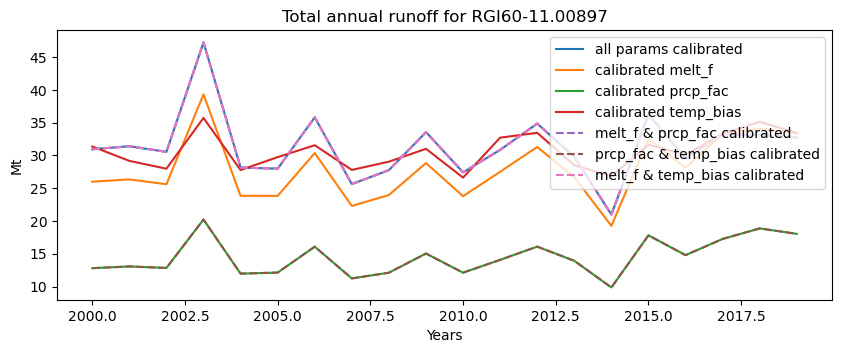

In [60]:
# Convert them to megatonnes (instead of kg)
wgms_df_runoff_melt_f = wgms_df_annual_melt_f[runoff_vars] * 1e-9
wgms_df_runoff_prcp_fac = wgms_df_annual_prcp_fac[runoff_vars] * 1e-9
wgms_df_runoff_temp_bias = wgms_df_annual_temp_bias[runoff_vars] * 1e-9
wgms_df_calib_all = wgms_df_annual_calib_all[runoff_vars] * 1e-9
wgms_df_runoff_mf_pf = wgms_df_annual_mf_pf[runoff_vars] * 1e-9
wgms_df_runoff_pf_tb = wgms_df_annual_pf_tb[runoff_vars] * 1e-9
wgms_df_runoff_mf_tb = wgms_df_annual_mf_tb[runoff_vars] * 1e-9

fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
wgms_df_calib_all.sum(axis=1).plot(ax=ax, label='all params calibrated');
wgms_df_runoff_melt_f.sum(axis=1).plot(ax=ax, label='calibrated melt_f');
wgms_df_runoff_prcp_fac.sum(axis=1).plot(ax=ax, label='calibrated prcp_fac');
wgms_df_runoff_temp_bias.sum(axis=1).plot(ax=ax, label='calibrated temp_bias');
wgms_df_runoff_mf_pf.sum(axis=1).plot(ax=ax, label='melt_f & prcp_fac calibrated', linestyle='dashed'); # This is overlapped with all_params calibrated
wgms_df_runoff_pf_tb.sum(axis=1).plot(ax=ax, label='prcp_fac & temp_bias calibrated', linestyle='dashed');
wgms_df_runoff_mf_tb.sum(axis=1).plot(ax=ax, label='melt_f & temp_bias calibrated', linestyle='dashed'); # This is also overlapped with all_params calibrated
plt.ylabel('Mt'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');
plt.legend();

It can be seen in the above graph for total annual runoff on the Hintereisferner glacier that the calibration of the mass-balance parameters through the WGMS calibration technique do in fact affect the runoff outputs.

Similarly to the Scalar Calibration method, some calibrations produce the same outputs as others and in the above graph it can be seen that:
- Calibrating all parameters together, melt_f and prcp_fac, melt_f and temp bias calibrated together produce the same runoff results.
- Calibrating the prcp_fac and calibrating the prcp_fac and temp_bias together produce the same runoff results.
- Calibrating with only melt_f produces unique runoff results.
- Calibrating with only temp_bias produces unique runoff results.

## Sensitvity Analysis for the WGMS Calibration

We will now perform sensitvity analysis on the parameters that have been calibrated by WGMS to investigate the relationship between the runoff parameters and the tuned parameters.

In [61]:
# calibrate the melt_f and fix the precipitation factor to different values 
# Create a dataframe with precip factor going from 0.1 to 5.0 in 0.3 steps
pd_prcp_fac_sens = pd.DataFrame(index=np.arange(0.1,5.0,0.3))

# Calibrate the melt factor for each of these values
spec_mb_prcp_fac_sens_dict = {}
for prcp_fac in pd_prcp_fac_sens.index:
    calib_param = mb_calibration_from_wgms_mb(gdir_hef,  
                                              prcp_fac = prcp_fac,
                                              overwrite_gdir=True)
    
    # Fill the dataframe with the calibrated parameters
    pd_prcp_fac_sens.loc[prcp_fac, 'melt_f'] = calib_param['melt_f']
     
    # Check the modelled massbalance
    mb_prcp_fac_sens = massbalance.MonthlyTIModel(gdir_hef)
    
    # ok, we actually matched the new ref_mb
    annual_mb = mb_prcp_fac_sens.get_specific_mb(h, w, year=np.arange(2000,2020,1))
    spec_mb_prcp_fac_sens_dict[prcp_fac] = annual_mb

        # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                        run_task=tasks.run_from_climate_data,  # running from real climate data
                        ys=2000,  # Period which we will average and constantly repeat
                        init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                        store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                        output_filesuffix=file_id);  # an identifier for the output file, to read it later
    
    
    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_sens:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds_sens = ds_sens.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds_sens.variables if 'month_2d' not in ds_sens[v].dims]
    df_annual_sens = ds_sens[sel_vars].to_dataframe()

    pd_prcp_fac_sens.loc[prcp_fac, 'melt_off_glacier'] = df_annual_sens['melt_off_glacier'].mean()
    pd_prcp_fac_sens.loc[prcp_fac, 'melt_on_glacier'] = df_annual_sens['melt_on_glacier'].mean()
    pd_prcp_fac_sens.loc[prcp_fac, 'liq_prcp_off_glacier'] = df_annual_sens['liq_prcp_off_glacier'].mean()
    pd_prcp_fac_sens.loc[prcp_fac, 'liq_prcp_on_glacier'] = df_annual_sens['liq_prcp_on_glacier'].mean()
    pd_prcp_fac_sens.loc[prcp_fac, 'runoff'] = pd_prcp_fac_sens.loc[prcp_fac, 'melt_off_glacier'] + pd_prcp_fac_sens.loc[prcp_fac, 'melt_on_glacier'] + pd_prcp_fac_sens.loc[prcp_fac, 'liq_prcp_off_glacier'] + pd_prcp_fac_sens.loc[prcp_fac, 'liq_prcp_on_glacier']


Investigating the sensitvity of the melt on glacier parameter to the precipitation factor:

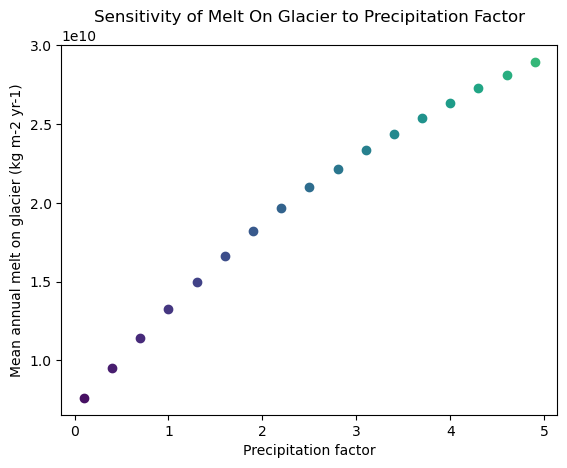

In [62]:
colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, prcp_fac in enumerate(pd_prcp_fac_sens.index):
    plt.plot(prcp_fac, pd_prcp_fac_sens.loc[prcp_fac, 'melt_on_glacier'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
    plt.title('Sensitivity of Melt On Glacier to Precipitation Factor')

In the above graph it can be seen that there is a strong correlation between the two parameters and that the larger a chosen `prcp_fac` is, the larger the annual mean melt on glacier needs to be when matching the same average mass balance.

Now investigating the sensitivity of the glacial melt contribution to the precipitation factor:

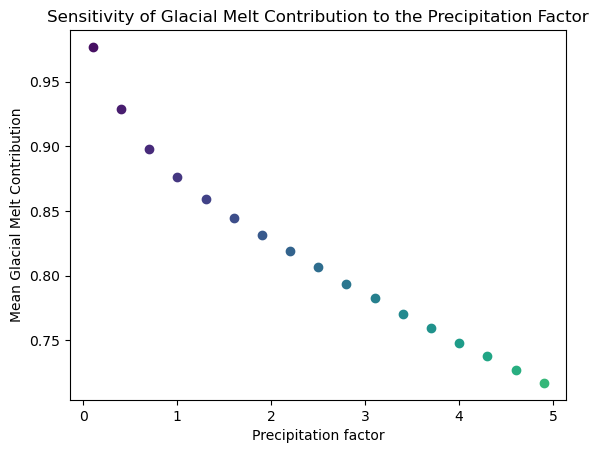

In [63]:
colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_fac_sens.index):
    plt.plot(pf, pd_prcp_fac_sens.loc[pf, 'melt_on_glacier']/pd_prcp_fac_sens.loc[pf, 'runoff'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean Glacial Melt Contribution')
    plt.title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

# Here we are plotting how the glacial melt contribution (melt_on_glacier/runoff) varies with the changing precipitation factor
# This shows how the relative contribution of glacier melt to total runoff changes as we adjust precipitation

In the above graph it can be seen that there is a strong negative correlation between the two parameters and that the larger a chosen `prcp_fac` is, the smaller the annual mean glacial melt contribution needs to be when matching the same average mass balance.

From the graph above showing the sensitivity of the glacier melt on parameter, and the definition we have for the glacial melt contribution. This shows that the runoff needs to be exceedingly larger for this correlation.

The correlation and behaviour of this parameter is similar to that of the first method and will be explored further in the preceeding sections.

## Comparison of calibration methods: **Runoff Outputs**

Now we have performed the analysis and looked into the results individually, let's compare the results from the two calibration methods and see how much our calibration to different parameters can affect both results. 

We will use the graphs outputted from this tutorial and view each calibration permutation on the same axes!

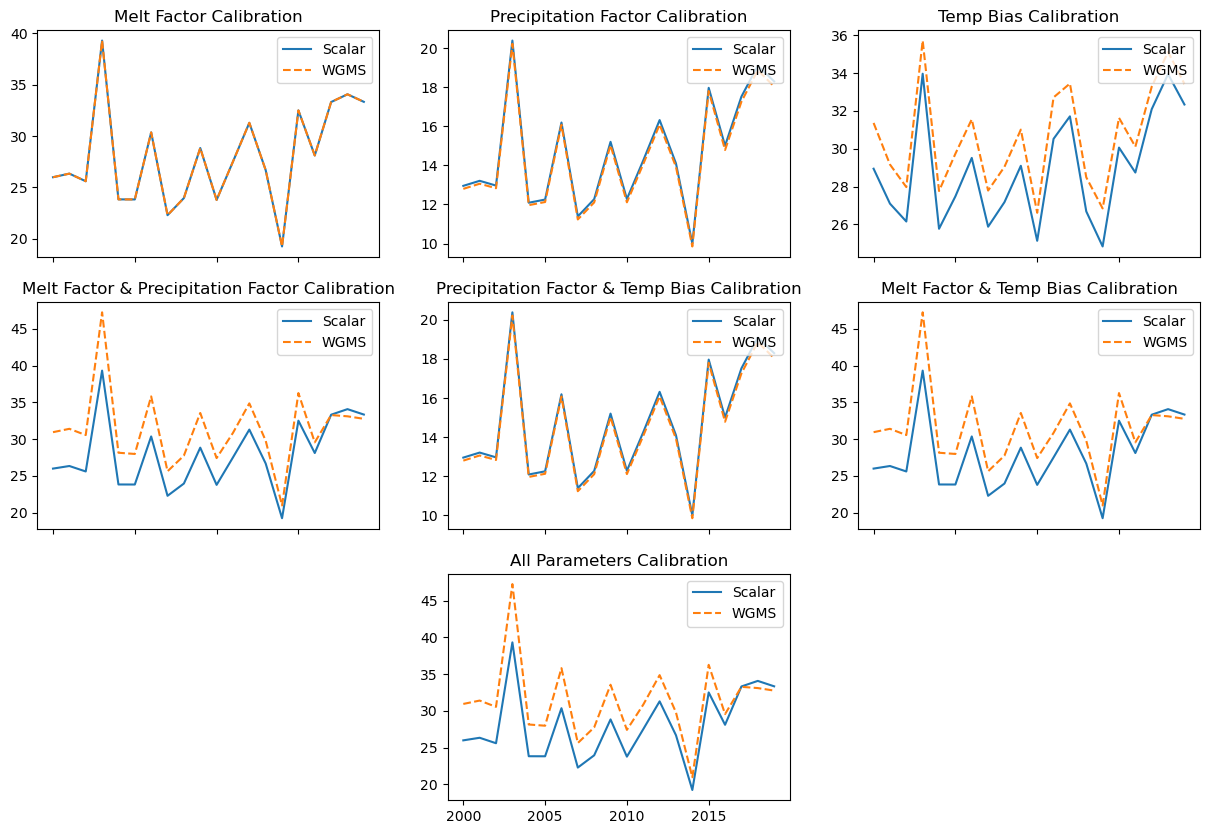

In [64]:
fig, axs = plt.subplots(3, 3, sharex=True, figsize=(15,10))

# The melt factor calibration
axs[0, 0].plot(df_runoff_melt_f.sum(axis=1), label='Scalar');
axs[0, 0].plot(wgms_df_runoff_melt_f.sum(axis=1), label='WGMS', linestyle='dashed');
axs[0,0].set_title('Melt Factor Calibration');
axs[0, 0].legend(loc='upper right');

# The precipitation factor calibration
axs[0, 1].plot(df_runoff_prcp_fac.sum(axis=1), label='Scalar');
axs[0, 1].plot(wgms_df_runoff_prcp_fac.sum(axis=1), label='WGMS', linestyle='dashed');
axs[0, 1].set_title('Precipitation Factor Calibration');
axs[0, 1].legend(loc='upper right');

# The temp bias calibration
axs[0, 2].plot(df_runoff_temp_bias.sum(axis=1), label='Scalar');
axs[0, 2].plot(wgms_df_runoff_temp_bias.sum(axis=1), label='WGMS', linestyle='dashed');
axs[0, 2].set_title('Temp Bias Calibration');
axs[0, 2].legend(loc='upper right');

# The melt factor and precipitation factor calibration
axs[1, 0].plot(df_runoff_mf_pf.sum(axis=1), label='Scalar');
axs[1, 0].plot(wgms_df_runoff_mf_pf.sum(axis=1), label='WGMS', linestyle='dashed');
axs[1, 0].set_title('Melt Factor & Precipitation Factor Calibration');
axs[1, 0].legend(loc='upper right');

# The precipitation factor and temperature bias calibration
axs[1, 1].plot(df_runoff_pf_tb.sum(axis=1), label='Scalar');
axs[1, 1].plot(wgms_df_runoff_pf_tb.sum(axis=1), label='WGMS', linestyle='dashed');
axs[1, 1].set_title('Precipitation Factor & Temp Bias Calibration');
axs[1, 1].legend(loc='upper right');

# The melt factor and temperature bias calibration
axs[1, 2].plot(df_runoff_mf_tb.sum(axis=1), label='Scalar');
axs[1, 2].plot(wgms_df_runoff_mf_tb.sum(axis=1), label='WGMS', linestyle='dashed');
axs[1, 2].set_title('Melt Factor & Temp Bias Calibration');
axs[1, 2].legend(loc='upper right');

# All parameters calibrated together
axs[2, 1].plot(df_calib.sum(axis=1), label='Scalar');
axs[2, 1].plot(wgms_df_calib_all.sum(axis=1), label='WGMS', linestyle='dashed');
axs[2, 1].set_title('All Parameters Calibration');
axs[2, 1].legend(loc='upper right');

axs[2, 0].set_visible(False)
axs[2, 2].set_visible(False)


It can be seen above that there is a relatively close match in calibration for the melt factor calibration, precipitation calibration, the precipitation factor and temp bias calbration. Which shows that regardless of methods, when calibrating this particular permutation of parameters in this tutorial the runoff outputs are similar.

However for the permutations for: melt factor and precipitation factor, melt factor and temp bias, temp bias alone and all parameters calibrated together, there are discrepancies in results with the WGMS calibration producing a mostly higher runoff.

This output is interesting and shows that calibration against different data sets, even when calibrating the same permutation of parameters, can cause different results! This is something to be aware of!

Now let's compare sensitvities to investigate how these differ with our two calibration methods.

## Comparison of calibration methods: **Sensitivity Analysis**

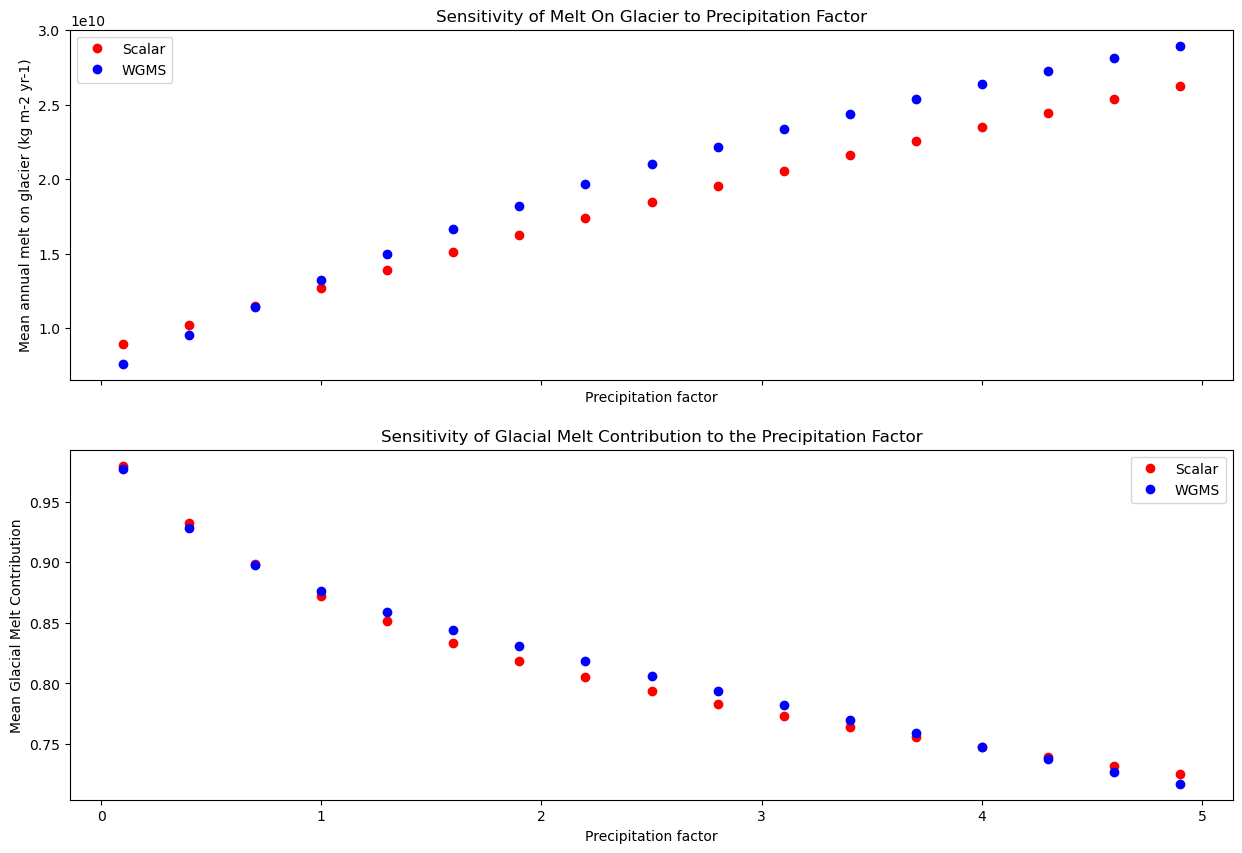

In [65]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(15,10))

# Scalar melt_on_glacier sensitivity to prcp_fac
axs[0].plot(pd_prcp_sens.index, pd_prcp_sens['melt_on_glacier'], 'o', color='r', label='Scalar')
axs[0].set_xlabel('Precipitation factor')
axs[0].set_ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
axs[0].set_title('Sensitivity of Melt On Glacier to Precipitation Factor')

# Scalar mean glacial melt contribution sensitivity to prcp_fac
axs[1].plot(pd_prcp_sens.index, pd_prcp_sens['melt_on_glacier']/pd_prcp_sens['runoff'], 'o', color='r', label='Scalar')
axs[1].set_xlabel('Precipitation factor')
axs[1].set_ylabel('Mean Glacial Melt Contribution')
axs[1].set_title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

# WGMS melt_on_glacier sensitivity to prcp_fac
axs[0].plot(pd_prcp_fac_sens.index, pd_prcp_fac_sens['melt_on_glacier'], 'o', color='b', label='WGMS')
axs[0].set_xlabel('Precipitation factor')
axs[0].set_ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
axs[0].set_title('Sensitivity of Melt On Glacier to Precipitation Factor')

# Scalar mean glacial melt contribution sensitivity to prcp_fac
axs[1].plot(pd_prcp_fac_sens.index, pd_prcp_fac_sens['melt_on_glacier']/pd_prcp_fac_sens['runoff'], 'o', color='b', label='WGMS')
axs[1].set_xlabel('Precipitation factor')
axs[1].set_ylabel('Mean Glacial Melt Contribution')
axs[1].set_title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

axs[0].legend();
axs[1].legend();




It can be seen above in the graphs comparing the effect of the precipitation factor on both the glacial melt contribution and mean annual melt on glacier, that both graphs have a similar trend for both calibration methods and both methods have a similar sensitivity to the Precipitation Factor. However it can be seen that for the Sensitivity Melt On Glacier to Precipitation Factor there are some diffrerences:
- For WGMS, for lower precipitation factor, the mean annual melt is lower until around a precipitation factor of 0.9, at which the values are the same for the both WGMS and Scalar methods.
- After this precipitation value is reached, the WGMS values are slightly higher than that of the Scalar method.

For the Sensitivity of Glacial Melt Contribution to the Precipitation Factor graph shown:
- The Scalar and WGMS values are similar at smaller precipitation factors, with the Scalar method having a slighly higher glacial melt contribution, as the precipitation factor increases, again around 0.9 the WGMS becomes the slighly higher value. This trend continues until the precipitation factor reaches the value of 4.0, at which both calibration methods produce the same glacial melt contribution value. Towards the higher precipitation values the WGMS method values are slightly less than the Scalar method once again.

**This investigation shows that again, despite exploring the same parameters, depending on the calibration techniques used the tuned parameters can have altering sensitivites based on the calibration technique used. Again, something to be aware of when calibrating!**

## Exercise:

Try this yourself for sensitivity with the precipitation factor when varying the melt factor as above:
1. The melt_off_glacier parameter.
2. The contribution of the melt_off_glacier (hint: see the above case for contribution).
3. The total liquid precipitation parameters (sum of on and off).
4. Any other interesting combinations you can discover!

Does anything you discover surprise you?
Are there particularly sensitive parameters compared to others?

**Stretch:** Can you experiment different combinations of parameters for sensitvity, e.g. such as varying the temp_bias parameters instead? 